# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras
from src.config import clean_data_file, reports_folder
from src.modeling import *

In [2]:
# Abrir archivo clean_data
df = pd.read_parquet(clean_data_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30012 entries, 4 to 33446
Data columns (total 76 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   CashAndCashEquivalents                  30012 non-null  float64       
 1   CurrentDebt                             30012 non-null  float64       
 2   LongTermDebt                            30012 non-null  float64       
 3   TotalDebt                               30012 non-null  float64       
 4   StockholdersEquity                      30012 non-null  float64       
 5   TotalAssets                             30012 non-null  float64       
 6   CurrentAssets                           30012 non-null  float64       
 7   CurrentLiabilities                      30012 non-null  float64       
 8   TotalNoncurrentLiabilities              30012 non-null  float64       
 9   TotalLiabilities                        30012 non-null 

## Feature Engineering

In [3]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [5]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Excluir las variables que tengan baja importancia para reducir el ruido
variables_no_significativas = [
]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Variable objetivo
    'MonthlyExcessReturn_Quantile',

    # Variables de volumen y precios crudos: 
    # No tiene sentido utilizarlas habiendo multiples tickers
    'Open',
    'Close',    
    'AverageDailyVolume_Lag1',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource'
    ]

# Se define la variable objetivo (categórica)
label = 'MonthlyExcessReturn_Quantile'

# Se separan los datos pasados de los del mes actual
# X_train / y_train: Todos los meses históricos completamente cerrados
# X_live / _ : El mes actual en curso (y_test se ignora porque es inválido)
X_train, X_live, y_train, _ = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Columnas numéricas: 
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

# Reemplazo de RandomForestRegressor por RandomForestClassifier
pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo clasificador con datos históricos completos...")
pipe.fit(X_train, y_train)
accuracy_completa = pipe.score(X_train, y_train)
print(f"Entrenamiento finalizado. Accuracy en histórico: {accuracy_completa:.4f}")

Entrenando el modelo clasificador con datos históricos completos...
Entrenamiento finalizado. Accuracy en histórico: 0.5587


In [6]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X_train, 
    y=y_train, 
    cv=tscv,         
    scoring='accuracy',
    n_jobs=-1        
)

print(f"Accuracy promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

Accuracy promedio Time Series CV: 0.2352 ± 0.0118


In [7]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(20)

,feature,importance
38,num__ShortTermBeta_Yeo,0.050751
29,num__MonthlyReturn_Lag1_Yeo,0.040842
46,cat__Industry,0.039724
34,num__AverageDailyVolume_Lag1_QoQ_Yeo,0.037761
40,num__ProfitMargins_Yeo,0.036752
41,num__ReturnOnAssets_Yeo,0.036191
28,num__MarketCap_Log1p,0.034653
25,num__AverageDailyVolume_Lag1_Acceleration,0.034256
17,num__AssetToMarket,0.033970
16,num__RevenueYield,0.032777


In [8]:
# Variables menos significativas
feature_importance_df.tail(20)

,feature,importance
37,num__EBITDA_TTM_YoY_Yeo,0.025742
18,num__FreeCashFlow_TTM_YoY,0.022677
20,num__CapitalExpenditure_TTM_YoY,0.021965
15,num__YearsSinceAdded,0.018251
45,cat__Sector,0.012112
12,num__EarningsYield_Quantile,0.007086
13,num__CapExToRevenue_Quantile,0.006633
14,num__TotalRevenue_TTM_Acceleration_Quantile,0.006129
11,num__EbitdaYield_Quantile,0.005876
6,num__EBITDA_TTM_YoY_IsMissing,0.000277


In [9]:
# Visualizar distribución de features
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
TotalRevenue_TTM_QoQ_IsMissing,29546.0,0.011812,0.108041,0.000000,0.000000,0.000000,0.000000,1.000000
EBITDA_TTM_QoQ_IsMissing,29546.0,0.011812,0.108041,0.000000,0.000000,0.000000,0.000000,1.000000
FreeCashFlow_TTM_QoQ_IsMissing,29546.0,0.011846,0.108194,0.000000,0.000000,0.000000,0.000000,1.000000
CapitalExpenditure_TTM_QoQ_IsMissing,29546.0,0.011812,0.108041,0.000000,0.000000,0.000000,0.000000,1.000000
AverageDailyVolume_Lag1_QoQ_IsMissing,29546.0,0.011812,0.108041,0.000000,0.000000,0.000000,0.000000,1.000000
TotalRevenue_TTM_YoY_IsMissing,29546.0,0.158126,0.364866,0.000000,0.000000,0.000000,0.000000,1.000000
EBITDA_TTM_YoY_IsMissing,29546.0,0.158126,0.364866,0.000000,0.000000,0.000000,0.000000,1.000000
FreeCashFlow_TTM_YoY_IsMissing,29546.0,0.158126,0.364866,0.000000,0.000000,0.000000,0.000000,1.000000
CapitalExpenditure_TTM_YoY_IsMissing,29546.0,0.158329,0.365056,0.000000,0.000000,0.000000,0.000000,1.000000
AverageDailyVolume_Lag1_YoY_IsMissing,29546.0,0.158160,0.364897,0.000000,0.000000,0.000000,0.000000,1.000000


## Aplicación del modelo

In [10]:
# Predicciones de la clase (Quintil 1 al 5)
y_pred_class = pipe.predict(X_live)

# Predicciones de probabilidad para desempatar y rankear
y_pred_proba = pipe.predict_proba(X_live)

# Extraer el modelo final del pipeline para conocer el orden de las clases
rf_model = pipe.named_steps['model']

# Identificar el índice de la columna que contiene la probabilidad del Quintil 5
idx_q5 = list(rf_model.classes_).index(5)
proba_q5 = y_pred_proba[:, idx_q5]

# Recuperar los Tickers correspondientes a X_live
tickers_test = df.loc[X_live.index, 'Ticker']

# Construir el DataFrame de resultados
resultados_agrupados = pd.DataFrame({
    'Ticker': tickers_test.values,
    'Predicted_Quantile': y_pred_class,
    'Probability_Q5': proba_q5
})

# Generar una señal (Cluster) de recomendación basada en la predicción del modelo
resultados_agrupados['Signal'] = np.where(
    resultados_agrupados['Predicted_Quantile'] == 5, 'Top_Quintile', 
    np.where(resultados_agrupados['Predicted_Quantile'] == 1, 'Bottom_Quintile', 'Neutral')
)

# Ordenar resultados por la probabilidad de pertenecer al Quintil 5 (de mayor a menor confianza)
resultados_agrupados = resultados_agrupados.sort_values(by='Probability_Q5', ascending=False)

# Mostrar el Top 10 de oportunidades según el modelo
print(resultados_agrupados.head(10).to_string(index=False))

Ticker  Predicted_Quantile  Probability_Q5       Signal
   WDC                   5        0.513586 Top_Quintile
    MU                   5        0.489325 Top_Quintile
   AMD                   5        0.446193 Top_Quintile
  VSAT                   5        0.434653 Top_Quintile
  LRCX                   5        0.428437 Top_Quintile
   TER                   5        0.423103 Top_Quintile
  MYRG                   5        0.419475 Top_Quintile
  AMKR                   5        0.404601 Top_Quintile
   STX                   5        0.399525 Top_Quintile
  SANM                   5        0.387068 Top_Quintile


In [11]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

# Crear carpeta si no existe y nombrar el archivo con la fecha
reports_folder.mkdir(parents=True, exist_ok=True)
nombre_archivo = f"{year}_{mes}_{dia}.csv"
ruta_completa = reports_folder / nombre_archivo

df_reporte.to_csv(ruta_completa, index=False)
print(f'Reporte exportado en la carpeta de datos.')
df_reporte.head()

Reporte exportado en la carpeta de datos.


,Ticker,Predicted_Quantile,Probability_Q5,Signal,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,...,AverageDailyVolume_Lag1_YoY_Yeo,EBITDA_TTM_QoQ_Yeo,EBITDA_TTM_YoY_Yeo,ShortTermBeta_Yeo,OperatingMargins_Yeo,ProfitMargins_Yeo,ReturnOnAssets_Yeo,ReturnOnEquity_Yeo,BookToMarket_Yeo,EnterpriseValue_Yeo
0,WDC,5,0.513586,Top_Quintile,2050.000,1581.000,2429.000,1581.000,9680.000,15045.000,...,1.088891,0.435885,1.792499,2.768135,1.358876,3.405856,4.034820,0.053124,-1.274708,1.035905
1,MU,5,0.489325,Top_Quintile,24995.000,3324.000,3052.000,6376.000,100724.000,134112.000,...,1.718927,0.649872,2.529382,5.141406,4.396928,3.442384,3.718463,0.027520,-1.081808,3.006476
2,AMD,5,0.446193,Top_Quintile,5585.000,874.000,2350.000,3871.000,64462.000,79642.000,...,-1.529769,0.007303,0.561378,5.198515,-0.217282,0.231177,-0.077362,-0.033198,-1.142727,2.759380
3,VSAT,5,0.434653,Top_Quintile,1746.835,57.753,6390.852,6939.566,4660.301,15226.596,...,-1.175393,-0.006194,2.723015,3.188334,-0.817033,-0.653011,-0.753471,-0.044720,0.109144,-0.293341
4,LRCX,5,0.428437,Top_Quintile,4750.936,4.095,3730.384,3734.479,10584.779,20791.910,...,0.555275,-0.048343,0.260777,1.557846,1.647501,1.605068,3.308084,0.047567,-1.421074,2.161450


## Explicabilidad del Modelo (SHAP)

In [12]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'WDC'

--- Explicación de la probabilidad de ser Quintil 5 para: WDC ---


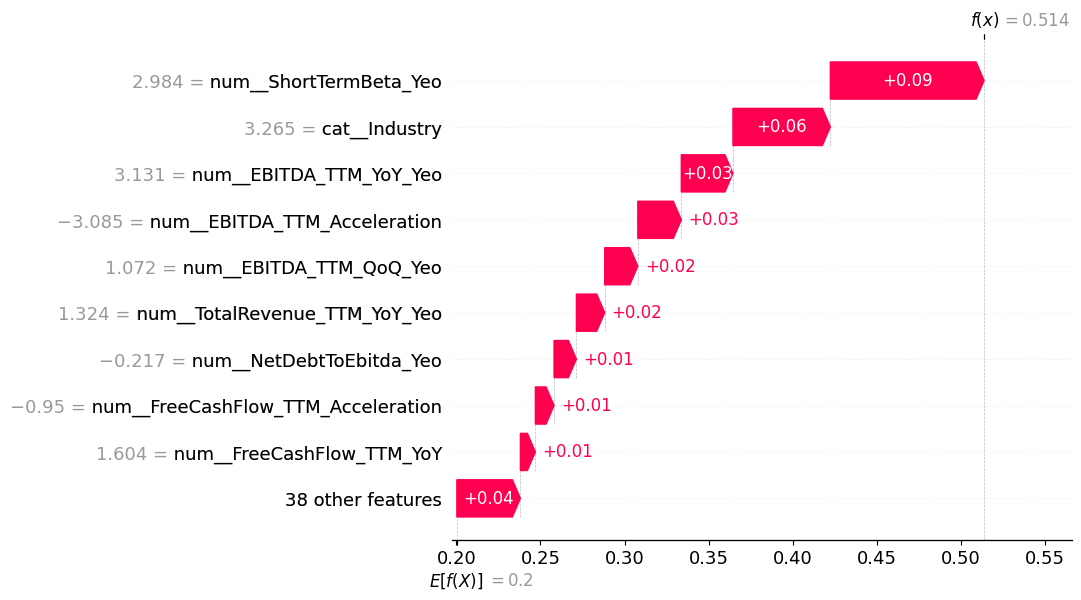

In [13]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_live)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_live.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test.values == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP
    shap_values = explainer(X_ticker_eval)
    
    # --- NUEVO: Seleccionar la explicación específica para la clase 5 (Quintil 5) ---
    idx_q5 = list(rf_model.classes_).index(5)
    shap_values_q5 = shap_values[..., idx_q5]
    
    print(f"--- Explicación de la probabilidad de ser Quintil 5 para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada
    shap.plots.waterfall(shap_values_q5[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [14]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest Classifier"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el clasificador
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestClassifier(random_state=42)) # Cambiado a Classifier
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV con la métrica correcta
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='accuracy', # Cambiado a accuracy (puedes usar 'balanced_accuracy' también)
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)